# « Développez une preuve de concept »

Projet n&#8239;$^\text{o}$ 7 du [cursus Machine Learning Engineer][2] d'OpenClassrooms

Auteur : [Kiril ISAKOV][1]

Mentor : Nicolas TISSERAND

Projet démarré le 18/05/2026

[1]: https://github.com/kirisakow/
[2]: https://openclassrooms.com/fr/paths/794-machine-learning-engineer

# Notebook d’entraînement du modèle SoTA `YOLO26` à 120 classes

Le dataset : http://vision.stanford.edu/aditya86/ImageNetDogs/

## Imports et constantes

In [ ]:
import os
# Déclarer le backend avant d'importer keras (sinon par défaut c'est 'tensorflow'):
os.environ["KERAS_BACKEND"] = "torch"
# Memory optimization: Enable expandable segments to reduce fragmentation:
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
# Limiter la verbosité des logs de tensorflow:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

from utils import (
    plot_confusion_matrix,
    plot_eigen_cam,
    print_classification_report,
    temp_dir_with_symlinks,
    WORDNET_ID_REGEX_PTRN
)
from collections import Counter
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tqdm.notebook import tqdm
from ultralytics import YOLO
import cv2
import datetime as dt
import itertools as it
import logging
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pytz
import re
import time
import torch
import warnings

logging.getLogger('tensorflow').setLevel(logging.ERROR)
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')  # Suppress Matplotlib warnings

LOGGER_FORMAT = '%(asctime)s [%(levelname)s] %(message)s'
logging.Formatter.converter = lambda *_: dt.datetime.now(pytz.timezone('Europe/Paris')).timetuple()
logging.basicConfig(level=logging.INFO, format=LOGGER_FORMAT, force=True)
logr = logging.getLogger(__name__)
logr.setLevel(logging.DEBUG)

## Split train - val - test

In [2]:
input_img_paths = tuple(
    # [Path('images/n02090379-redbone'), Path('images/n02085936-Maltese_dog'), Path('images/n02088094-Afghan_hound')]
    Path('images/').glob('*/')
)
logr.info(f"Nombre de classes retenues pour l'entraînement : {len(input_img_paths)}")
input_img_paths = tuple(path.glob('*.jpg') for path in input_img_paths)
input_img_paths = tuple(it.chain.from_iterable(input_img_paths))
logr.info(f"Nombre d'images retenues pour l'entraînement : {len(input_img_paths)}")
breed_labels = tuple(str(path).split('/')[1] for path in input_img_paths)
breed_labels = tuple(WORDNET_ID_REGEX_PTRN.split(label_with_id)[1] for label_with_id in breed_labels)
n = 1000
logr.info(f"Un échantillon de la distribution des classes (seuls les {n} premiers chemins sont comptés) :")
display(dict(Counter(breed_labels[:n])))
train_frac = 0.8
input_paths_train, input_paths_val_test, labels_train, labels_val_test = train_test_split(
    input_img_paths, breed_labels, train_size=train_frac,
    random_state=42, shuffle=True, stratify=breed_labels,
)
val_test_frac = 0.5
input_paths_val, input_paths_test, labels_val, labels_test = train_test_split(
    input_paths_val_test, labels_val_test, train_size=val_test_frac,
    random_state=42, shuffle=True, stratify=labels_val_test
)
del input_paths_val_test, labels_val_test, n
logr.info(f"Taile de l'échantillon de train ({train_frac}): {len(input_paths_train)}")
logr.info(f"Taile de l'échantillon de val ({round(val_test_frac * (1 - train_frac), 1)}): {len(input_paths_val)}")
logr.info(f"Taile de l'échantillon de test ({round(val_test_frac * (1 - train_frac), 1)}): {len(input_paths_test)}")

2026-06-28 22:05:23,660 [INFO] Nombre de classes retenues pour l'entraînement : 120


2026-06-28 22:05:23,738 [INFO] Nombre d'images retenues pour l'entraînement : 20580
2026-06-28 22:05:23,755 [INFO] Un échantillon de la distribution des classes (seuls les 1000 premiers chemins sont comptés) :


{'briard': 152,
 'vizsla': 154,
 'kuvasz': 150,
 'papillon': 196,
 'African_hunting_dog': 169,
 'Great_Pyrenees': 179}

2026-06-28 22:05:23,786 [INFO] Taile de l'échantillon de train (0.8): 16464
2026-06-28 22:05:23,787 [INFO] Taile de l'échantillon de val (0.1): 2058
2026-06-28 22:05:23,788 [INFO] Taile de l'échantillon de test (0.1): 2058


## Entraînement

### Déclarer les paramètres

In [3]:
DEFAULT_BATCH_SIZE = 8
DEFAULT_TOP_K_CATEG_ACCUR = 5
DEFAULT_TRGT_IMG_SIZE = (224, 224)
DO_NOT_AUTOSAVE = -1
LEARNING_RATE_LOW = 1e-5
LEARNING_RATE_REGULAR = 1e-3
N_EPOCHS = 20
PRETR_MDL_LBL = 'yolo26m-cls'
N_CLASSES = len(set(breed_labels))
CLASS_NAMES_SORTED = sorted(set(breed_labels))
YOLO_BACKBONE_SIZE = 10
LAYERS_TO_UNFREEZE = 2
TOP_K_CATEG_ACCUR = min(DEFAULT_TOP_K_CATEG_ACCUR, N_CLASSES - 1)
TEMP_DIR_WITH_SYMLINKS = temp_dir_with_symlinks(input_paths_train, input_paths_val, input_paths_test)

### Training: Stage 1: freeze backbone, train head and neck

In [4]:
experiment_name = (
    f'CNN__from={PRETR_MDL_LBL}'
    f'__n_cls={N_CLASSES}'
    f'__n_eps={N_EPOCHS}'
    f'__LR={LEARNING_RATE_REGULAR}'
    f'__FT={LAYERS_TO_UNFREEZE}'
    f'__stage1'
)

In [5]:
PATH_TO_MDL_STG1 = f'models/{experiment_name}.pt'
if os.path.exists(PATH_TO_MDL_STG1):
    logr.info(f"Loading saved model {PATH_TO_MDL_STG1!r}")
    model = YOLO(PATH_TO_MDL_STG1)
else:
    logr.info(f"Training {experiment_name}")
    logr.info("Stage 1: freeze backbone, train head and neck")
    model = YOLO(f'{PRETR_MDL_LBL}.pt')
    results = model.train(
        batch=DEFAULT_BATCH_SIZE,
        data=TEMP_DIR_WITH_SYMLINKS,
        device=0 if torch.cuda.is_available() else 'cpu',
        epochs=N_EPOCHS,
        exist_ok=True,
        freeze=YOLO_BACKBONE_SIZE,
        imgsz=DEFAULT_TRGT_IMG_SIZE[0],
        lr0=LEARNING_RATE_REGULAR,
        name=experiment_name,
        save_dir=f"log/{experiment_name}",
        save_period=DO_NOT_AUTOSAVE,
        verbose=True,
    )
    logr.info("Training Stage 1 complete.")
    logr.info(f"Saving model to {PATH_TO_MDL_STG1!r}")
    model.save(PATH_TO_MDL_STG1)

2026-06-28 22:05:28,778 [INFO] Loading saved model 'models/CNN__from=yolo26m-cls__n_cls=120__n_eps=20__LR=0.001__FT=2__stage1.pt'


### Training: Stage 2: unfreeze part of the backbone, fine-tune with lower learning rate

In [6]:
torch.cuda.empty_cache()

In [7]:
experiment_name = (
    f'CNN__from={PRETR_MDL_LBL}'
    f'__n_cls={N_CLASSES}'
    f'__n_eps={N_EPOCHS}'
    f'__LR={LEARNING_RATE_LOW}'
    f'__FT={LAYERS_TO_UNFREEZE}'
    f'__stage2'
)

In [8]:
PATH_TO_MDL_STG2 = f'models/{experiment_name}.pt'
if os.path.exists(PATH_TO_MDL_STG2):
    logr.info(f"Loading saved model {PATH_TO_MDL_STG2!r}")
    model = YOLO(PATH_TO_MDL_STG2)
else:
    logr.info(f"Training {experiment_name}")
    logr.info("Stage 2: unfreeze whole backbone, fine-tune with lower LR")
    model = YOLO(PATH_TO_MDL_STG1)
    results = model.train(
        batch=DEFAULT_BATCH_SIZE,
        data=TEMP_DIR_WITH_SYMLINKS,
        device=0 if torch.cuda.is_available() else 'cpu',
        epochs=N_EPOCHS,
        exist_ok=True,
        freeze=YOLO_BACKBONE_SIZE - LAYERS_TO_UNFREEZE,
        imgsz=DEFAULT_TRGT_IMG_SIZE[0],
        lr0=LEARNING_RATE_LOW,
        name=experiment_name,
        save_dir=f"log/{experiment_name}",
        save_period=DO_NOT_AUTOSAVE,
        verbose=True,
    )
    logr.info("Training Stage 2 complete.")
    logr.info(f"Saving model to {PATH_TO_MDL_STG2!r}")
    model.save(PATH_TO_MDL_STG2)

2026-06-28 22:05:28,995 [INFO] Loading saved model 'models/CNN__from=yolo26m-cls__n_cls=120__n_eps=20__LR=1e-05__FT=2__stage2.pt'


## Évaluation sur les données de test

In [9]:
torch.cuda.empty_cache()

### Metrics

In [10]:
logr.info("Evaluating on test set...")
metrics = model.val(
    batch=DEFAULT_BATCH_SIZE,
    data=TEMP_DIR_WITH_SYMLINKS,
    device=0 if torch.cuda.is_available() else 'cpu',
    exist_ok=True,
    save_dir=f"log/{experiment_name}",
    save_period=DO_NOT_AUTOSAVE,
    split='test',
    verbose=True,
)
logr.info(f"Metrics :\n\n{metrics}")

2026-06-28 22:01:22,091 [INFO] Evaluating on test set...


Ultralytics 8.4.75 🚀 Python-3.12.3 torch-2.12.0+cu132 CUDA:0 (NVIDIA GeForce RTX 2070 with Max-Q Design, 7778MiB)
YOLO26m-cls summary (fused): 57 layers, 10,495,352 parameters, 0 gradients, 39.4 GFLOPs
train: /tmp/ultralytics_tempdir_9ly74vj4/train... found 16464 images in 120 classes ✅ 
val: /tmp/ultralytics_tempdir_9ly74vj4/val... found 2058 images in 120 classes ✅ 
test: /tmp/ultralytics_tempdir_9ly74vj4/test... found 2058 images in 120 classes ✅ 
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 9.8±5.2 MB/s, size: 45.6 KB)
test: Scanning /tmp/ultralytics_tempdir_9ly74vj4/test... 2058 images, 0 corrupt: 100% ━━━━━━━━━━━━ 2058/2058 293.9it/s 7.0s0.1s
test: New cache created: /tmp/ultralytics_tempdir_9ly74vj4/test.cache
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 258/258 32.3it/s 8.0s0.1s
                   all      0.875       0.99
Speed: 0.1ms preprocess, 2.0ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /home/mira/kiril_dev/oc-dogs-cv-d

2026-06-28 22:01:40,351 [INFO] Metrics :

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x71047cb37a10>
curves: []
curves_results: []
fitness: 0.9322157502174377
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.8746355772018433, 'metrics/accuracy_top5': 0.9897959232330322, 'fitness': 0.9322157502174377}
save_dir: PosixPath('/home/mira/kiril_dev/oc-dogs-cv-dl-poc/log/CNN__from=yolo26m-cls__n_cls=120__n_eps=20__LR=1e-05__FT=2__stage2')
speed: {'preprocess': 0.14791121138205462, 'inference': 2.035137912043706, 'loss': 0.0012893197228648972, 'postprocess': 0.002196141894343576}
top1: 0.8746355772018433
top5: 0.9897959232330322


### Classification Report & Confusion Matrix

In [11]:
y_true = []
y_pred_probs = []
y_pred_topk = []
for path, label in tqdm(zip(input_paths_test, labels_test), total=len(input_paths_test), leave=False):
    results = model(path, verbose=False)
    probs = results[0].probs.data.cpu().numpy()
    y_pred_probs.append(probs)
    true_idx = CLASS_NAMES_SORTED.index(label)
    y_true.append(true_idx)
    top_k_idx = np.argpartition(probs, -TOP_K_CATEG_ACCUR)[-TOP_K_CATEG_ACCUR:]
    y_pred_topk.append(true_idx in top_k_idx)
y_true_arr = np.array(y_true)
y_pred_arr = np.array(y_pred_probs)
print("\nClassification Report:\n")
print_classification_report(y_true_arr, y_pred_arr, class_labels=CLASS_NAMES_SORTED)
print("\nConfusion Matrix:\n")
plot_confusion_matrix(y_pred_arr, y_true_arr, CLASS_NAMES_SORTED, title=experiment_name)
top_k_accuracy = sum(y_pred_topk) / len(y_pred_topk)
print(f"\nTop-{TOP_K_CATEG_ACCUR} Accuracy: {top_k_accuracy:.4f}\n")

  0%|          | 0/2058 [00:00<?, ?it/s]


Classification Report:

                                precision    recall  f1-score   support

                  Afghan_hound       1.00      1.00      1.00        24
           African_hunting_dog       1.00      1.00      1.00        17
                      Airedale       0.87      1.00      0.93        20
American_Staffordshire_terrier       0.85      0.65      0.73        17
                   Appenzeller       0.89      0.53      0.67        15
            Australian_terrier       0.79      0.75      0.77        20
            Bedlington_terrier       1.00      1.00      1.00        18
          Bernese_mountain_dog       0.91      0.95      0.93        22
              Blenheim_spaniel       0.90      1.00      0.95        19
                 Border_collie       0.63      0.80      0.71        15
                Border_terrier       0.89      1.00      0.94        17
                   Boston_bull       0.89      0.94      0.92        18
          Bouvier_des_Flandres       0

<Figure size 600x400 with 2 Axes>


Top-5 Accuracy: 0.9898



## Prédiction en mode *blind test*

In [9]:
DEFAULT_BLIND_TEST_SAMPLE_SIZE = 100
random_idx = np.random.choice(
    len(input_paths_test),
    size=min(DEFAULT_BLIND_TEST_SAMPLE_SIZE, len(input_paths_test)),
    replace=False,
)
blind_test_sample = np.array(input_paths_test)[random_idx]
blind_test_labels = np.array(labels_test)[random_idx]

Effectuer l'inférence :

In [10]:
start_time = time.perf_counter()
predicted_class_idx = []
for path in blind_test_sample:
    results = model(path, verbose=False)
    pred_idx = results[0].probs.top5[0]
    predicted_class_idx.append(pred_idx)
end_time = time.perf_counter()
print(f"\nInference time on a sample of size {len(blind_test_sample)}: {end_time - start_time:.2f}s")


Inference time on a sample of size 100: 1.60s


Afficher les résultats sous une forme conviviale :

In [11]:
df = pd.DataFrame({
    'path': blind_test_sample,
    'expected_breed': blind_test_labels,
    'predicted_breed': [CLASS_NAMES_SORTED[pred_idx] for pred_idx in predicted_class_idx],
}, dtype=str)
df['is_correct'] = df.apply(
    lambda row: '✅' if row['predicted_breed'] in row['path'] else '❗️',
    axis=1
)
default_max_rows = pd.options.display.max_rows
pd.options.display.max_rows = DEFAULT_BLIND_TEST_SAMPLE_SIZE
display(df)
pd.options.display.max_rows = default_max_rows

,path,expected_breed,predicted_breed,is_correct
0,images/n02091467-Norwegian_elkhound/n02091467_...,Norwegian_elkhound,Norwegian_elkhound,✅
1,images/n02088094-Afghan_hound/n02088094_4352.jpg,Afghan_hound,Afghan_hound,✅
2,images/n02088094-Afghan_hound/n02088094_5927.jpg,Afghan_hound,Afghan_hound,✅
3,images/n02097209-standard_schnauzer/n02097209_...,standard_schnauzer,standard_schnauzer,✅
4,images/n02085782-Japanese_spaniel/n02085782_24...,Japanese_spaniel,Japanese_spaniel,✅
5,images/n02106166-Border_collie/n02106166_7803.jpg,Border_collie,Border_collie,✅
6,images/n02101006-Gordon_setter/n02101006_4470.jpg,Gordon_setter,Gordon_setter,✅
7,images/n02093647-Bedlington_terrier/n02093647_...,Bedlington_terrier,Bedlington_terrier,✅
8,images/n02091244-Ibizan_hound/n02091244_119.jpg,Ibizan_hound,Ibizan_hound,✅
9,images/n02087394-Rhodesian_ridgeback/n02087394...,Rhodesian_ridgeback,Rhodesian_ridgeback,✅


## Interprétabilité

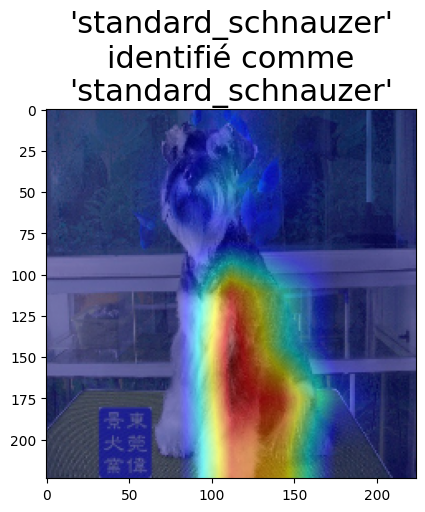

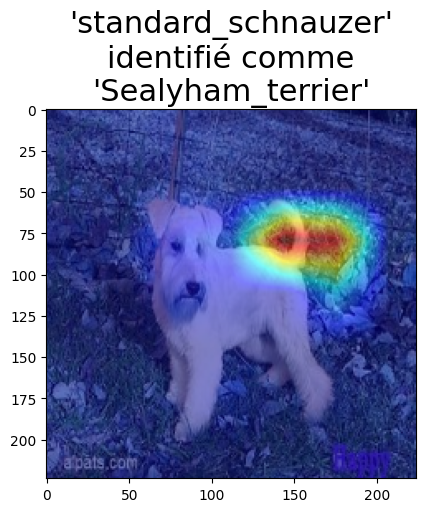

In [15]:
prediction_OK_idx, prediction_KO_idx = 3, 90
for i in [prediction_OK_idx, prediction_KO_idx]:
    plot_eigen_cam(
        path_to_img=df.loc[i, 'path'],
        img_size=DEFAULT_TRGT_IMG_SIZE,
        expected_cls=df.loc[i, 'expected_breed'],
        predicted_cls=df.loc[i, 'predicted_breed'],
        model=model,
        layers_to_unfreeze=LAYERS_TO_UNFREEZE,
        task='cls',
    )